# autio实验

## 线性缩放与响度感知

音频信号 $x$ 是一个向量，其每个元素 $x_i$ 代表一个采样点。我们通过标量乘法 $y = ax$ 来改变音量。

通过计算均方根（RMS）和声压级（SPL），验证对数增长规律。

放大 4 倍: 理论上 SPL 增加约 $20 \log_{10}(4) \approx 12.04$ dB。

相位反转 ($a=-1$): 听觉上与原声一致，验证了物理能量相等。

In [ ]:
import numpy as np
from scipy.io import wavfile
import os

# 1. 读取音频数据
# sample_rate 是采样率 (1/h)，data 是音频向量 x
current_dir = os.path.dirname(os.path.abspath(__file__))
sample_rate, x1 = wavfile.read(os.path.join(current_dir, "..", "data", "钢琴背景音.wav"))

# 音频是一个向量 x，每个元素 x_i 是一个采样点 [cite: 13, 17]
x = x.astype(np.float32)/ 32768.0  # 归一化到 [-1, 1] 范围

# 2. 进行缩放实验
# a > 1 听起来应该明显变大
a1 = 4.0
y_louder = a1 * x

# a < 1 听起来应该明显变小
a2 = 0.1
y_quieter = a2 * x

# a = -1: 听起来应该和原声一模一样
a3 = -1.0
y_inverse = a3 * x

def calculate_spl(x_norm):
    # 计算均方根 RMS 
    rms_p = np.sqrt(np.mean(x_norm**2))
    # 定义参考声压 
    p_ref = 2e-5 
    # 计算分贝 SPL 
    spl = 20 * np.log10(rms_p / p_ref)
    return rms_p, spl
   
rms_p0, spl0 = calculate_spl(x)
rms_p1, spl1 = calculate_spl(y_louder)
rms_p2, spl2 = calculate_spl(y_quieter)
rms_p3, spl3 = calculate_spl(y_inverse)


# 3. 保存并导出结果
# 注意：写回文件前需要转回整数格式 (int16)
def save_wav(name, data, rate):
    # 限制范围防止爆音
    data = np.clip(data* 32768.0, -32768, 32767)
    wavfile.write(name, rate, data.astype(np.int16))

save_wav("output_louder.wav", y_louder, sample_rate)
save_wav("output_quieter.wav", y_quieter, sample_rate)
save_wav("output_inverse.wav", y_inverse, sample_rate)

print("实验文件已生成：")
print("1. output_louder.wav 4")
print("2. output_quieter.wav (0.1倍音量)")
print("3. output_inverse.wav (反相音频)")

print(f"原声平均有效声压 (rms(p)): {rms_p0:.6f} N/m^2") # 
print(f"原声计算出的响度 (SPL): {spl0:.2f} dB") #

print(f"变大音频平均有效声压 (rms(p)): {rms_p1:.6f} N/m^2") # 
print(f"变大音频计算出的响度 (SPL): {spl1:.2f} dB") #

print(f"变小音频平均有效声压 (rms(p)): {rms_p2:.6f} N/m^2") # 
print(f"变小音频计算出的响度 (SPL): {spl2:.2f} dB") #

print(f"反相音频平均有效声压 (rms(p)): {rms_p3:.6f} N/m^2") # 
print(f"反相音频计算出的响度 (SPL): {spl3:.2f} dB") #

实验文件已生成：
1. output_louder.wav 4
2. output_quieter.wav (0.1倍音量)
3. output_inverse.wav (反相音频)
原声平均有效声压 (rms(p)): 0.114038 N/m^2
原声计算出的响度 (SPL): 75.12 dB
变大音频平均有效声压 (rms(p)): 0.456153 N/m^2
变大音频计算出的响度 (SPL): 87.16 dB
变小音频平均有效声压 (rms(p)): 0.011404 N/m^2
变小音频计算出的响度 (SPL): 55.12 dB
反相音频平均有效声压 (rms(p)): 0.114038 N/m^2
反相音频计算出的响度 (SPL): 75.12 dB


注意sample_rate, x = wavfile.read(r"/home/eve/Desktop/音频/钢琴背景音.wav")里要使用绝对路径，或者使用os.path.expanduser，会自动把~当作用户的家目录，保证代码在不同机器上的兼容性。

如果音频与代码放在同一个目录下面的话就可以直接读取。

通过 wavfile.read 得到的是“数字量化值”，而除以 32768 后得到的是“物理声压比例”。

sample_rate, x = wavfile.read(...) 得到的是一个 16 位整数向量，除以 32768 实际上是设定了一个标准的 $\alpha$。它将硬件的“满格”状态映射为数学上的 $1.0$ 。

为了符合关于声压级（SPL）的物理定义 ，我们将 wavfile.read 获取的原始量化数据除以 $32768$ 。这一步有效地确定了缩放因子 $\alpha$，使得计算出的 $rms(p)$ 能够与参考声压 $p_{ref}$ 在同一量纲下进行对数运算，从而准确估算音频的响度 。

## 多音轨线性混合

信号正交性分析在混合钢琴背景音 $x_1$ 和人声 $x_2$ 前，计算它们的余弦相似度。

计算公式: $\text{Similarity} = \frac{x_1 \cdot x_2}{\|x_1\| \|x_2\|}$。

实验发现: 两个音轨的相似度极低，说明它们在数学上接近正交。

为了防止线性组合 $y = a_1x_1 + a_2x_2$ 导致的“爆音”，实现动态缩放函数safe_normalize()。

In [ ]:
import numpy as np
from scipy.io import wavfile
import os

def load_and_standardize(path):
    sample_rate, data = wavfile.read(path)
    # 转换为浮点数并归一化到 -1 到 1 之间，方便处理
    data = data.astype(np.float32) / 32768.0
    # 如果是双声道，取其中一个声道简化处理
    if len(data.shape) > 1:
        data = data[:, 0]
    return sample_rate, data

# 1. 读取两个音轨
current_dir = os.path.dirname(os.path.abspath(__file__))
rate1, x1 = wavfile.read(os.path.join(current_dir, "..", "data", "钢琴背景音.wav"))
rate2, x2 = wavfile.read(os.path.join(current_dir, "..", "data", "人声.wav"))

if rate1 != rate2:
    raise ValueError(f"警告：采样率不匹配！钢琴是{rate1}Hz，人声是{rate2}Hz。请先重采样。")

# 2. 确保长度一致 (取较短的那一个，对应讲义中 same length 的要求)
n = min(len(x1), len(x2))
x1, x2 = x1[:n], x2[:n]

inner_prod = np.dot(x1, x2)
similarity = inner_prod / (np.linalg.norm(x1) * np.linalg.norm(x2))
print(f"两种声音的数学相关性 (Similarity): {similarity:.4f}")

# 3. 混合实验 (对应讲义第 7 页的 Mix 1, 2, 3)

# 方案 A: 均匀混合 (a1=0.5, a2=0.5)
y_balanced = 0.5 * x1 + 0.5 * x2

# 方案 B: 突出音轨2 (例如人声为主，背景音很小)
y_vocal_focus = 0.05 * x1 + 0.95 * x2

# 方案 C: 讲义中的负权重尝试 (虽然 |a| 决定音量，但可以看看相位抵消)
y_diff = 0.5 * x1 - 0.5 * x2

def safe_normalize(data, threshold=1.0):
    """
    判断合成函数的幅值，如果超过阈值则进行整体线性缩放。
    """
    # 找到当前信号的峰值（绝对值的最大值）
    peak = np.max(np.abs(data))
    
    # 如果峰值超过了阈值，进行缩放
    if peak > threshold:
        print(f"检测到幅值溢出 (Peak={peak:.4f})，正在进行线性缩放...")
        # 核心逻辑：整个向量除以峰值，将其压回到 [-1, 1] 空间
        # 这保持了 x1 和 x2 之间的相对比例（线性组合关系不变）
        data = data / peak
    else:
        print(f"信号幅值安全 (Peak={peak:.4f})。")
        
    return data

y_balanced = safe_normalize(y_balanced)
y_vocal_focus = safe_normalize(y_vocal_focus)
y_diff = safe_normalize(y_diff)

# 4. 导出结果
def save_mix(name, data, rate):
    # 重新映射回 int16 范围
    data = np.clip(data * 32768.0, -32768, 32767)
    wavfile.write(name, rate, data.astype(np.int16))
#
save_mix("mix_balanced.wav", y_balanced, rate1)
# save_mix("mix_vocal_focus.wav", y_vocal_focus, rate1)
#save_mix("mix_diff.wav", y_diff, rate1)
#save_mix("mix_diff_double_piano.wav", y_diff, rate1)

print("实验二文件已生成：")
print("1. mix_balanced.wav (均衡混音)")
print("2. mix_vocal_focus.wav (突出第二音轨)")
print("3. mix_diff.wav (减法混音)")

## 音色合成与音程数学

谐波叠加原理根据公式 $p(t) = \sum c_k \sin(2\pi f k t)$ 合成信号。

纯音: 仅包含基频。复合音: 引入谐波系数 $c = [0.7, 0.6, 0.3, 0.04]$。





十二平均律计算利用频率比 $2^{n/12}$ 计算不同音程。

中音 C: 频率约为 523.2 Hz（比 A 高 3 个半音）。

In [ ]:
import numpy as np
from scipy.io import wavfile

# 基本设置
fs = 44100  # 采样率 (1/h) [cite: 19, 20]
duration = 2.0  # 持续2秒
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

def generate_tone(f, harmonics, time_array):
    """
    根据讲义公式生成信号: p(t) = sum(ck * sin(2 * pi * f * k * t))
    """
    signal = np.zeros_like(time_array)
    for k, ck in enumerate(harmonics):
        # f_k = f * (k + 1) 是第 k+1 个谐波
        signal += ck * np.sin(2 * np.pi * f * (k + 1) * time_array)
    return signal

# --- 任务 A: 音色对比 (讲义第12-13页) ---
f_A = 440.0  # 中音 A

# 1. 纯正弦波 (枯燥的音色) c = (1, 0, ...)
c_pure = [1.0]
tone_pure = generate_tone(f_A, c_pure, t)

# 2. 丰富音色 c = (0.7, 0.6, 0.3, 0.04) [cite: 92]
c_rich = [0.7, 0.6, 0.3, 0.04]
tone_rich = generate_tone(f_A, c_rich, t)

# --- 任务 B: 音程计算 (讲义第9-10页) ---
# 计算中音 C (比 A 高 3 个半音)
f_C = (2**(3/12)) * 440.0  # 约 523.2 Hz [cite: 81]
tone_C = generate_tone(f_C, c_rich, t)

# 保存文件
def export_wav(filename, signal):
    # 归一化处理
    signal = signal / np.max(np.abs(signal)) * 0.5
    wavfile.write(filename, fs, (signal * 32767).astype(np.int16))

export_wav("3_tone_pure.wav", tone_pure)
export_wav("3_tone_rich.wav", tone_rich)
export_wav("3_tone_C_major.wav", tone_C)

print("实验三文件已生成：")
print("- 3_tone_pure.wav: 纯正弦波 (A440)")
print("- 3_tone_rich.wav: 丰富音色 (A440)")
print("- 3_tone_C_major.wav: 使用丰富音色演奏的中音 C")

## 结果可视化与波形对比

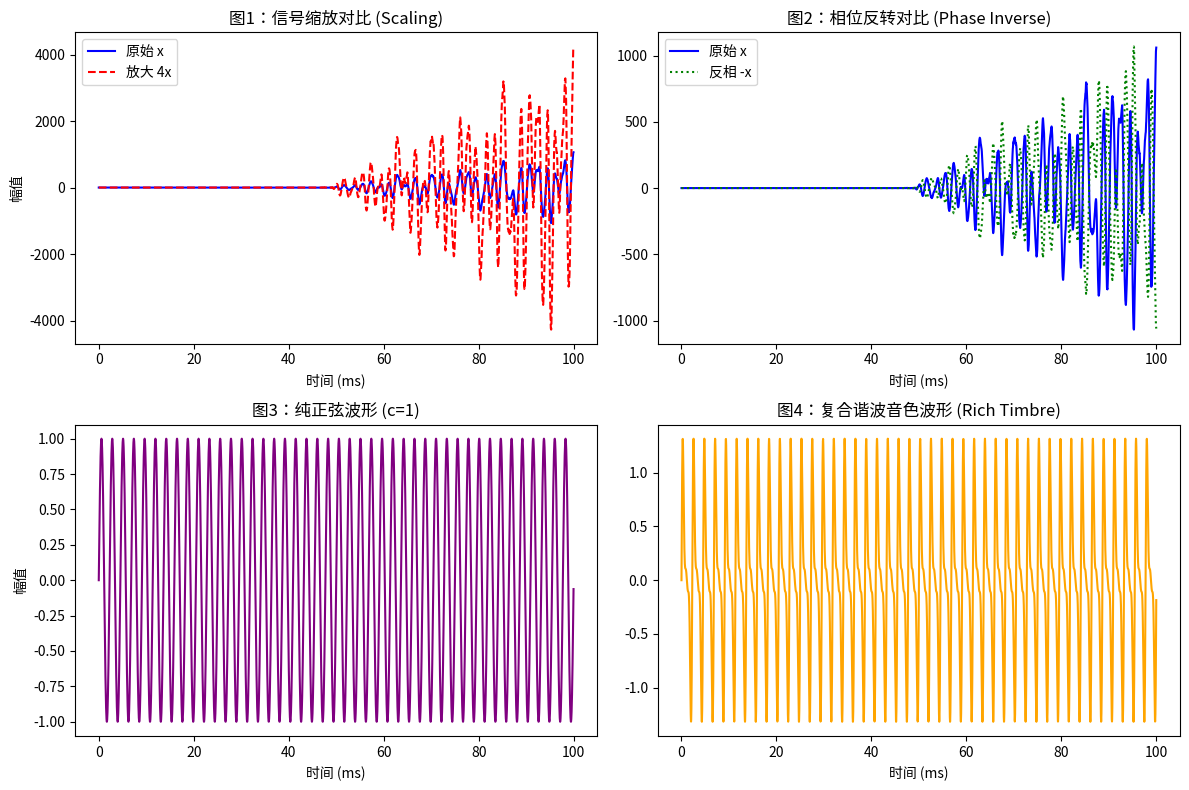

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 设置中文显示
#plt.rcParams['font.sans-serif'] = ['SimHei']
#plt.rcParams['axes.unicode_minus'] = False
#Linux 系统上常见的字体替代方案，确保中文显示正常
# 1. 尝试使用 Linux 下最通用的开源中文字体名称
linux_fonts = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'DejaVu Sans']

# 2. 自动寻找可用的字体
plt.rcParams['font.sans-serif'] = linux_fonts + plt.rcParams['font.sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 必须加上，否则负号显示为方块

# 1. 定义观察时间窗口 (0.1s)
fs = 44100
t_window = 0.1  # 0.1s
num_samples = int(fs * t_window)
t = np.linspace(0, t_window, num_samples, endpoint=False)

# 2. 读取并裁剪信号
current_dir = os.path.dirname(os.path.abspath(__file__))
rate1, x_full = wavfile.read(os.path.join(current_dir, "..", "data", "钢琴背景音.wav"))

# 如果是双声道，取左声道
if len(x_full.shape) > 1:
    x_full = x_full[:, 0]

# 【关键点】只取前 num_samples 个点，确保与 t 长度一致
x = x_full[:num_samples].astype(np.float32)

# 3. 实验数据处理
y_louder = 4.0 * x  # 缩放系数 a=4 [cite: 41]
y_inverse = -1.0 * x  # 相位反转 -x [cite: 44]

# 4. 实验三音色合成 (纯正弦波用于对比) [cite: 88, 89]
y_pure = np.sin(2 * np.pi * 440 * t)
c_rich = [0.7, 0.6, 0.3, 0.04]
y_rich = sum(ck * np.sin(2 * np.pi * 440 * (k+1) * t) for k, ck in enumerate(c_rich))

# 5. 绘图
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# 子图1: 缩放对比
axs[0, 0].plot(t*1000, x, label='原始 x', color='blue')
axs[0, 0].plot(t*1000, y_louder, '--', label='放大 4x', color='red')
axs[0, 0].set_title("图1：信号缩放对比 (Scaling)")
axs[0, 0].set_ylabel("幅值")
axs[0, 0].legend()

# 子图2: 相位对比
axs[0, 1].plot(t*1000, x, label='原始 x', color='blue')
axs[0, 1].plot(t*1000, y_inverse, ':', label='反相 -x', color='green')
axs[0, 1].set_title("图2：相位反转对比 (Phase Inverse)")
axs[0, 1].legend()

# 子图3: 纯音波形
axs[1, 0].plot(t*1000, y_pure, color='purple')
axs[1, 0].set_title("图3：纯正弦波形 (c=1)")
axs[1, 0].set_ylabel("幅值")

# 子图4: 复合音色波形
axs[1, 1].plot(t*1000, y_rich, color='orange')
axs[1, 1].set_title("图4：复合谐波音色波形 (Rich Timbre)")

for ax in axs.flat:
    ax.set_xlabel("时间 (ms)")

plt.tight_layout()
plt.show()